# Superstore Sales Analysis using SQL
## Celebal Technologies – Week 3 Assessment
**Name:** Ashmit Gupta

This notebook covers:
- Loading data into a raw table
- Creating tables from it
- Using Subqueries, CTEs, and Window Functions
- Answering some basic business questions


## Setup

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("superstore.db")

def run_query(sql):
    return pd.read_sql_query(sql, conn)

print("Connected!")


Connected!


## Step 1 – Look at the Raw Data

First let's just see what our table looks like.

In [2]:
run_query("SELECT * FROM superstore_raw LIMIT 5")


,row_id,order_id,order_date,customer_id,segment,category,sub_category,product_id,product_name,sales,quantity,discount,profit
0,1,CA-2020-152156,2020-11-08,CA-2011-100006,Consumer,Furniture,Bookcases,FUR-BO-10001798,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2020-152156,2020-11-08,CA-2011-100006,Consumer,Furniture,Chairs,FUR-CH-10000454,Hon Deluxe Fabric Upholstered Stacking Chairs,731.94,3,0.00,219.58
2,3,CA-2020-138688,2020-06-12,CA-2011-100006,Consumer,Office Supplies,Labels,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters,14.62,2,0.00,6.87
3,4,US-2020-108966,2020-10-11,US-2012-118983,Corporate,Office Supplies,Storage,OFF-ST-10000760,Wirebound Message Books,22.37,2,0.45,-16.08
4,5,US-2020-108966,2020-10-11,US-2012-118983,Corporate,Furniture,Tables,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03


In [3]:
# Basic counts
run_query("""
SELECT
    COUNT(*) as total_rows,
    COUNT(DISTINCT customer_id) as customers,
    COUNT(DISTINCT order_id) as orders,
    ROUND(SUM(sales), 2) as total_sales
FROM superstore_raw
""")


,total_rows,customers,orders,total_sales
0,50,14,26,15737.79


## Step 2 – Creating Tables from Raw Data

We split the raw table into 3 smaller tables so it's easier to work with.

In [4]:
# Customers table
run_query("SELECT * FROM customers LIMIT 5")


,customer_id,segment
0,CA-2011-100006,Consumer
1,US-2012-118983,Corporate
2,CA-2011-167248,Consumer
3,CA-2013-139619,Consumer
4,CA-2014-143567,Corporate


In [5]:
# Products table
run_query("SELECT * FROM products LIMIT 5")


,product_id,product_name,category,sub_category
0,FUR-BO-10001798,Bush Somerset Collection Bookcase,Furniture,Bookcases
1,FUR-CH-10000454,Hon Deluxe Fabric Upholstered Stacking Chairs,Furniture,Chairs
2,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters,Office Supplies,Labels
3,OFF-ST-10000760,Wirebound Message Books,Office Supplies,Storage
4,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,Furniture,Tables


In [6]:
# Orders table
run_query("SELECT * FROM orders LIMIT 5")


,order_id,order_date,customer_id,product_id,sales,quantity,discount,profit
0,CA-2020-152156,2020-11-08,CA-2011-100006,FUR-BO-10001798,261.96,2,0.00,41.91
1,CA-2020-152156,2020-11-08,CA-2011-100006,FUR-CH-10000454,731.94,3,0.00,219.58
2,CA-2020-138688,2020-06-12,CA-2011-100006,OFF-LA-10000240,14.62,2,0.00,6.87
3,US-2020-108966,2020-10-11,US-2012-118983,OFF-ST-10000760,22.37,2,0.45,-16.08
4,US-2020-108966,2020-10-11,US-2012-118983,FUR-TA-10000577,957.58,5,0.45,-383.03


## Step 3 – Subqueries

A subquery is just a query inside another query. The inner one runs first.

### 3A. Orders where sales are more than the average

In [7]:
run_query("""
SELECT order_id, customer_id, ROUND(sales,2) as sales
FROM orders
WHERE sales > (SELECT AVG(sales) FROM orders)
ORDER BY sales DESC
""")


,order_id,customer_id,sales
0,CA-2022-143567,CA-2014-143567,1399.98
1,CA-2023-201234,CA-2020-201234,1325.85
2,CA-2023-167890,CA-2016-167890,1299.99
3,CA-2022-143567,CA-2014-143567,1099.98
4,CA-2023-234567,CA-2023-234567,1099.98
5,CA-2023-192345,CA-2019-192345,979.98
6,US-2020-108966,US-2012-118983,957.58
7,CA-2020-115812,CA-2011-167248,907.15
8,CA-2023-212345,CA-2021-212345,899.99
9,CA-2020-152156,CA-2011-100006,731.94


### 3B. Each customer's biggest order

In [8]:
run_query("""
SELECT o.customer_id, o.order_id, ROUND(o.sales,2) as top_sale
FROM orders o
WHERE o.sales = (
    SELECT MAX(o2.sales)
    FROM orders o2
    WHERE o2.customer_id = o.customer_id
)
ORDER BY top_sale DESC
""")


,customer_id,order_id,top_sale
0,CA-2014-143567,CA-2022-143567,1399.98
1,CA-2020-201234,CA-2023-201234,1325.85
2,CA-2016-167890,CA-2023-167890,1299.99
3,CA-2023-234567,CA-2023-234567,1099.98
4,CA-2019-192345,CA-2023-192345,979.98
5,US-2012-118983,US-2020-108966,957.58
6,CA-2011-167248,CA-2020-115812,907.15
7,CA-2021-212345,CA-2023-212345,899.99
8,CA-2011-100006,CA-2020-152156,731.94
9,CA-2017-178901,CA-2023-178901,599.00


## Step 4 – CTEs (Common Table Expressions)

A CTE is like saving a query result with a name so you can use it again below.
Written as: `WITH name AS (query) SELECT ...`

### 4A. Total sales per customer

In [9]:
run_query("""
WITH customer_sales AS (
    SELECT customer_id,
           ROUND(SUM(sales), 2) as total_sales,
           COUNT(DISTINCT order_id) as num_orders
    FROM orders
    GROUP BY customer_id
)
SELECT cs.customer_id, c.segment, cs.total_sales, cs.num_orders
FROM customer_sales cs
JOIN customers c ON cs.customer_id = c.customer_id
ORDER BY total_sales DESC
""")


,customer_id,segment,total_sales,num_orders
0,CA-2014-143567,Corporate,3716.44,2
1,CA-2016-167890,Consumer,1762.47,2
2,CA-2021-212345,Corporate,1514.54,2
3,CA-2011-167248,Consumer,1454.00,1
4,CA-2020-201234,Consumer,1420.37,2
5,CA-2019-192345,Home Office,1138.18,2
6,CA-2023-234567,Home Office,1119.34,1
7,CA-2011-100006,Consumer,1012.06,3
8,US-2012-118983,Corporate,979.95,1
9,CA-2017-178901,Corporate,753.65,2


### 4B. Top 5 customers by sales

In [10]:
run_query("""
WITH customer_sales AS (
    SELECT customer_id, ROUND(SUM(sales),2) as total_sales
    FROM orders
    GROUP BY customer_id
)
SELECT customer_id, total_sales
FROM customer_sales
ORDER BY total_sales DESC
LIMIT 5
""")


,customer_id,total_sales
0,CA-2014-143567,3716.44
1,CA-2016-167890,1762.47
2,CA-2021-212345,1514.54
3,CA-2011-167248,1454.00
4,CA-2020-201234,1420.37


### 4C. Bottom 5 customers (low spenders)

In [11]:
run_query("""
WITH customer_sales AS (
    SELECT customer_id, ROUND(SUM(sales),2) as total_sales
    FROM orders
    GROUP BY customer_id
)
SELECT customer_id, total_sales
FROM customer_sales
ORDER BY total_sales ASC
LIMIT 5
""")


,customer_id,total_sales
0,CA-2015-155678,87.32
1,CA-2018-189012,122.12
2,CA-2022-223456,315.81
3,CA-2013-139619,341.54
4,CA-2017-178901,753.65


## Step 5 – Window Functions

Window functions work on a "window" of rows without collapsing them like GROUP BY.

### 5A. ROW_NUMBER – number rows inside each category

In [12]:
run_query("""
SELECT p.category, p.product_name, ROUND(o.sales,2) as sales,
       ROW_NUMBER() OVER (PARTITION BY p.category ORDER BY o.sales DESC) as row_num
FROM orders o
JOIN products p ON o.product_id = p.product_id
LIMIT 15
""")


,category,product_name,sales,row_num
0,Furniture,Bretford Rectangular Conference Room Tables,1325.85,1
1,Furniture,Bretford CR4500 Series Slim Rectangular Table,957.58,2
2,Furniture,Hon Deluxe Fabric Upholstered Stacking Chairs,731.94,3
3,Furniture,Sauder Classic Bookcase Traditional Cherry Finish,500.94,4
4,Furniture,Hon Metal Bookcases,291.84,5
5,Furniture,Bush Somerset Collection Bookcase,261.96,6
6,Furniture,Tenex B1-RE Series Executive Desk Risers,170.32,7
7,Furniture,Howard Miller 11.75 Diameter Brushed Chrome Ro...,89.00,8
8,Furniture,Howard Miller 11.75 Diameter Brushed Chrome Ro...,89.00,9
9,Furniture,Global Leather Task Chair Black,75.25,10


### 5B. RANK – rank customers by total sales

In [13]:
run_query("""
SELECT customer_id,
       ROUND(SUM(sales),2) as total_sales,
       RANK() OVER (ORDER BY SUM(sales) DESC) as rank
FROM orders
GROUP BY customer_id
""")


,customer_id,total_sales,rank
0,CA-2014-143567,3716.44,1
1,CA-2016-167890,1762.47,2
2,CA-2021-212345,1514.54,3
3,CA-2011-167248,1454.00,4
4,CA-2020-201234,1420.37,5
5,CA-2019-192345,1138.18,6
6,CA-2023-234567,1119.34,7
7,CA-2011-100006,1012.06,8
8,US-2012-118983,979.95,9
9,CA-2017-178901,753.65,10


### 5C. Running Total of sales over time

In [14]:
run_query("""
SELECT order_date, order_id, ROUND(sales,2) as sale,
       ROUND(SUM(sales) OVER (ORDER BY order_date), 2) as running_total
FROM orders
ORDER BY order_date
LIMIT 12
""")


,order_date,order_id,sale,running_total
0,2020-06-09,CA-2020-115812,22.37,1454.00
1,2020-06-09,CA-2020-115812,7.28,1454.00
2,2020-06-09,CA-2020-115812,907.15,1454.00
3,2020-06-09,CA-2020-115812,18.50,1454.00
4,2020-06-09,CA-2020-115812,114.90,1454.00
5,2020-06-09,CA-2020-115812,170.32,1454.00
6,2020-06-09,CA-2020-115812,213.48,1454.00
7,2020-06-12,CA-2020-138688,14.62,1468.62
8,2020-10-11,US-2020-108966,22.37,2448.57
9,2020-10-11,US-2020-108966,957.58,2448.57


## Step 6 – Combining JOIN + CTE + Window Function

This one query does everything together – totals, joining segment info, and ranking.

In [15]:
run_query("""
WITH totals AS (
    SELECT customer_id,
           ROUND(SUM(sales),2) as total_sales,
           ROUND(SUM(profit),2) as total_profit,
           COUNT(DISTINCT order_id) as orders
    FROM orders
    GROUP BY customer_id
),
ranked AS (
    SELECT *, RANK() OVER (ORDER BY total_sales DESC) as sales_rank
    FROM totals
)
SELECT r.sales_rank, r.customer_id, c.segment,
       r.orders, r.total_sales, r.total_profit
FROM ranked r
JOIN customers c ON r.customer_id = c.customer_id
ORDER BY sales_rank
""")


,sales_rank,customer_id,segment,orders,total_sales,total_profit
0,1,CA-2014-143567,Corporate,2,3716.44,981.22
1,2,CA-2016-167890,Consumer,2,1762.47,478.93
2,3,CA-2021-212345,Corporate,2,1514.54,210.17
3,4,CA-2011-167248,Consumer,1,1454.00,153.16
4,5,CA-2020-201234,Consumer,2,1420.37,152.55
5,6,CA-2019-192345,Home Office,2,1138.18,244.92
6,7,CA-2023-234567,Home Office,1,1119.34,336.96
7,8,CA-2011-100006,Consumer,3,1012.06,269.95
8,9,US-2012-118983,Corporate,1,979.95,-399.11
9,10,CA-2017-178901,Corporate,2,753.65,64.86


## Step 7 – Business Questions

### Q1. Customers who placed only 1 order

In [16]:
run_query("""
SELECT customer_id, COUNT(DISTINCT order_id) as num_orders
FROM orders
GROUP BY customer_id
HAVING COUNT(DISTINCT order_id) = 1
""")


,customer_id,num_orders
0,CA-2011-167248,1
1,CA-2022-223456,1
2,CA-2023-234567,1
3,US-2012-118983,1


### Q2. Customers with above-average total spending

In [17]:
run_query("""
WITH totals AS (
    SELECT customer_id, ROUND(SUM(sales),2) as total_sales
    FROM orders
    GROUP BY customer_id
)
SELECT customer_id, total_sales
FROM totals
WHERE total_sales > (SELECT AVG(total_sales) FROM totals)
ORDER BY total_sales DESC
""")


,customer_id,total_sales
0,CA-2014-143567,3716.44
1,CA-2016-167890,1762.47
2,CA-2021-212345,1514.54
3,CA-2011-167248,1454.00
4,CA-2020-201234,1420.37
5,CA-2019-192345,1138.18


### Q3. Sales by Category

In [18]:
run_query("""
SELECT p.category,
       ROUND(SUM(o.sales),2) as total_sales,
       ROUND(SUM(o.profit),2) as total_profit
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY total_sales DESC
""")


,category,total_sales,total_profit
0,Technology,10562.86,2418.68
1,Furniture,4663.28,129.10
2,Office Supplies,511.65,2.25


### Q4. Most profitable sub-categories

In [19]:
run_query("""
SELECT p.sub_category,
       ROUND(SUM(o.profit),2) as total_profit
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.sub_category
ORDER BY total_profit DESC
LIMIT 8
""")


,sub_category,total_profit
0,Machines,825.97
1,Phones,802.33
2,Copiers,731.86
3,Chairs,235.81
4,Bookcases,86.12
5,Accessories,58.52
6,Furnishings,57.62
7,Art,44.11


## Step 8 – Simple Charts

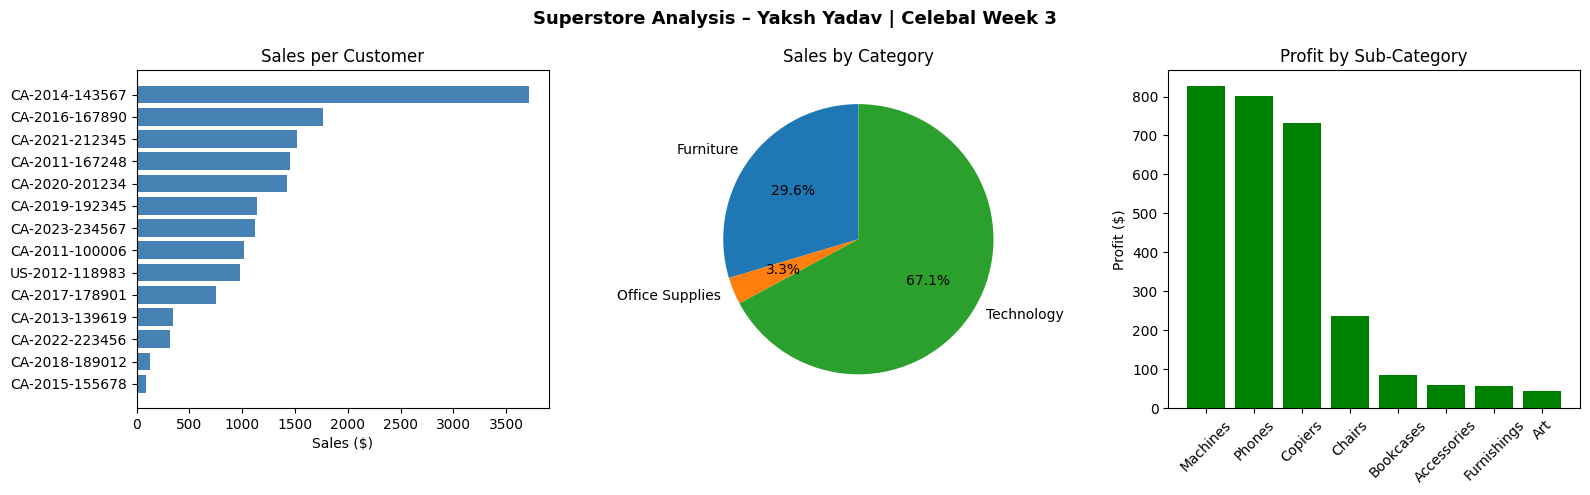

In [20]:
import matplotlib.pyplot as plt

# get data
cust = pd.read_sql_query(
    "SELECT customer_id, ROUND(SUM(sales),2) as total_sales FROM orders GROUP BY customer_id ORDER BY total_sales DESC",
    conn)

cat = pd.read_sql_query(
    "SELECT p.category, ROUND(SUM(o.sales),2) as total_sales FROM orders o JOIN products p ON o.product_id=p.product_id GROUP BY p.category",
    conn)

sub = pd.read_sql_query(
    "SELECT p.sub_category, ROUND(SUM(o.profit),2) as profit FROM orders o JOIN products p ON o.product_id=p.product_id GROUP BY p.sub_category ORDER BY profit DESC LIMIT 8",
    conn)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Superstore Analysis – Yaksh Yadav | Celebal Week 3", fontsize=13, fontweight='bold')

axes[0].barh(cust['customer_id'], cust['total_sales'], color='steelblue')
axes[0].set_title("Sales per Customer")
axes[0].set_xlabel("Sales ($)")
axes[0].invert_yaxis()

axes[1].pie(cat['total_sales'], labels=cat['category'], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Sales by Category")

colors = ['green' if p > 0 else 'red' for p in sub['profit']]
axes[2].bar(sub['sub_category'], sub['profit'], color=colors)
axes[2].set_title("Profit by Sub-Category")
axes[2].set_ylabel("Profit ($)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("charts.png", bbox_inches='tight')
plt.show()


## Brief Insights

After running all the queries on the Superstore dataset, here are some things I noticed:

1. **Technology products bring in the most sales.** Copiers and Phones are the top sellers. Customers in the Corporate segment tend to buy more tech items.

2. **Some orders have negative profit.** This happens mostly when the discount is very high (like 45% or 80%). So giving too much discount hurts the business.

3. **A few customers are doing most of the buying.** The top customer `CA-2014-143567` spent over $3,700, while some customers spent less than $100. This shows a big gap.

4. **Several customers placed only 1 order.** These could be one-time buyers. The business should try to bring them back with offers.

5. **Furniture Tables and Chairs sometimes lose money.** Even though sales numbers look okay, the profit is negative on some orders — again because of discounts.

6. **Copiers and Machines are the most profitable sub-categories** when not discounted. These are good products for the business to focus on.

---
*Ashmit Gupta | Celebal Technologies – Week 3 Assessment*


In [21]:
conn.close()
print("Done!")


Done!
